This tutorial will walk you through the different steps to train a neural network to learn a differentaition potential informed by labelled RNA from temporal single cell RNA, using FLOWSTATE.The dataset used is a subset of the mouse embryonic stem cell dataset from Maizels et al, 2023. Cells have been sequenced for consecutive days following a 2h labelling period. 

# imports 

In [1]:
%load_ext autoreload

In [2]:
import os 
#os.environ["JAX_PLATFORMS"] = "cpu"
import flowstate
import anndata as ad
import jax
import optax 
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
pd.__version__

'2.3.3'

Check that JAX detects the GPU. If not, refer to the JAX installation page. https://docs.jax.dev/en/latest/installation.html#nvidia-gpu

In [4]:
jax.devices()

[cuda(id=0)]

In [5]:
colors=  {
        'NMP':'#00afff',
        'Mesoderm':'#20c505',
        'Early_Neural':'#db00ff',
        'Neural':'#ff00a7',
        'p3':'#ffab02',
        'V3':'#ffd966',
        'pMN':'#ff0000',
        'MN':'#ff8080',
        'FP':'#a52a2a',
    }


# Load data 

In [6]:
# Select a given number of principal components then normalize the embeddings.
adata = ad.read_h5ad('/pasteur/helix/projects/ml4ig_hot/Users/aaudit/pasteur_stage/data/scifi2/kinetic_velo/jac/full.h5ad')


adata.obsm['X_pca'] = adata.obsm['X_pca'][:, : 20]
adata.obsm['v_pca_scaled'] = adata.obsm['v_pca_scaled'][:, :20]

k = adata.obsm['X_pca'].max()
adata.obsm['v_pca_scaled'] /= k
adata.obsm['X_pca'] /= k
    

In [7]:
# Initialize the model.
model = flowstate.FlowState( l=0.25, epsilon=0.05)

The model is trained using model.fit(), which allows you to specify parameters such as the number of iterations and batch size. We use the AdamW optimizer with a cosine decay learning-rate schedule. Training is stopped automatically when the validation loss does not improve for a sufficient number of iteration. The weights corresponding to the best validation loss are kept.

The `l` parameter controls the weight given to the information derived from labelled RNA. Larger values place more emphasis on this additional term, while l = 0 ignores the labelling information. The velo parameter determines how the velocity information from labelled RNA is incorporated: with `velo="accumulated"`, the model reconstructs a past cell state and compares the model-predicted accumulated velocity with the observed trajectory, whereas with `velo="instantaneous"`, labelled RNA is assumed to provide an instantaneous estimate of velocity, which is compared with the velocity predicted by the model. 
In this dataset, since the labelling duration (2 h) is short compared with the interval between timepoints (1 day), we use the second mode (`velo="instantaneous"`).



In [8]:
scheduler = optax.cosine_decay_schedule(0.005, 10_000)
model.fit(
            adata=adata,
            time_key='timepoint',
            omics_key="X_pca",
            velo_omics_key = 'v_pca_scaled',
            weight_key='growth',
            optimizer=optax.adamw(scheduler), 
            velo= "instantaneous",
        )

[3. 4. 5. 6. 7. 8.]
the batch size is : 838


/pasteur/helix/projects/ml4ig_hot/Users/aaudit/proj1/flowstate/model.py:113: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  time_old = jnp.array(time_old)
 24%|██▍       | 3591/15000 [30:34<1:37:08,  1.96it/s, iteration=3592, train_loss=0.060057666, val_loss=0.059139807]

Met early stopping criteria, breaking...


# Compute and display the potential

The compute_potential fonction adds a new field to the adata.obs containing the value of the learned differentiation potential for each cell. Cells in a more mature state have lower potential value 

/pasteur/helix/projects/ml4ig_hot/Users/aaudit/proj1/flowstate/tools.py:216: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = np.array(potential_fn(adata.obsm[omics_key]))


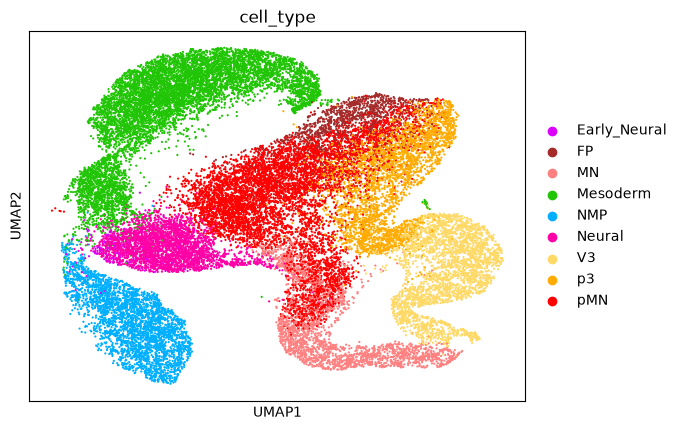

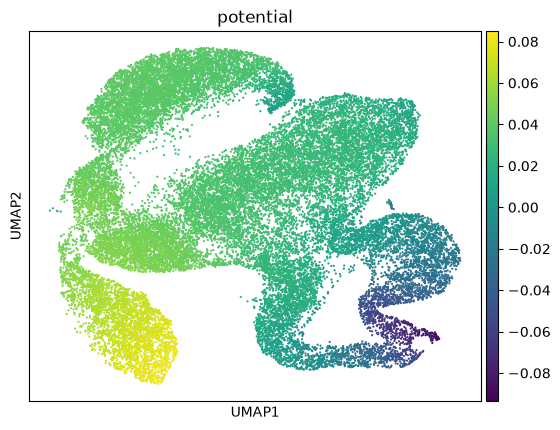

In [9]:
adata = adata[adata.obs["cell_type"] != "Other"]
flowstate.tools.compute_potential(adata,model, "X_pca")
sc.pl.umap (adata ,color ="cell_type",  s= 10, palette=colors )
sc.pl.umap (adata ,color = 'potential', s= 10, palette="viridis" )

# Display the velocity 

The velocity of a cell is obtained by taking minus the gradient of the differentiation potential. This can be easily computed with the compute_velocity fonction a wrapper around CellRank which adds adata.obsm["X_velo"] to the adata object  

In [10]:
flowstate.tools.compute_velocity(adata, model, "X_pca")

/pasteur/appa/homes/aaudit/anaconda3/envs/flowstate_gpu_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 31567/31567 [00:03<00:00, 9227.59cell/s]


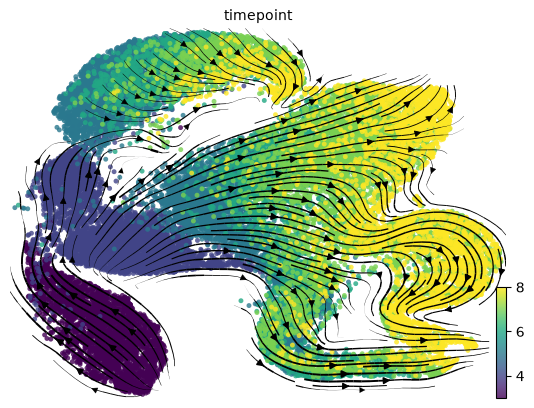

In [11]:
# Plot velocity
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20, random_state=0)
flowstate.tools.plot_velocity(adata,omics_key="X_pca",basis="X_umap",color="timepoint", s=50, alpha=0.8, palette="viridis")

# Explore gene trends and transcription factors 

We can now explore gene expression trends along the trajectory. For each gene, its expression is regressed against the potential. This adds `adata.layers["regression"]`, containing the regressed expression values, as well as two gene-level information in `adata.var`: `adata.var["regression_score"]`, which measures the quality of the regression fit for each gene, and `adata.var["regression_argmax"]`, which indicates the potential value at which the regressed expression reaches its maximum for each gene.

The `select_driver_genes` function identifies genes whose expression is most strongly correlated with the potential, while also selecting genes whose maximum regressed expression occurs at different stages along the trajectory. 


This information can then be vizualized using `plot_gene_trends`. Since the cells are ordered by potential more mature cells are located on the left of the plot.  

24967it [14:53, 27.96it/s]


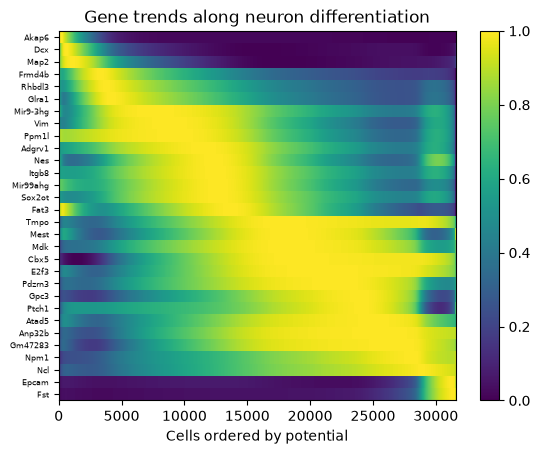

In [12]:
flowstate.tools.regress_genes(adata)
sorted_genes_names = flowstate.tools.select_driver_genes(adata, n_stages=10, n_genes=3)
fig, axes = flowstate.tools.plot_gene_trends(
    adata, sorted_genes_names, title="Gene trends along neuron differentiation"
)

Here, we use the CollecTRI regulatory network to identify transcription factors whose target genes are enriched among genes strongly associated with the potential. `tf_enrich` performs a one-sided Wilcoxon rank-sum test for each TF, comparing the regression scores of its target genes with those of non-target genes. 

  9%|▉         | 102/1134 [00:26<01:28, 11.62it/s]

100%|██████████| 1134/1134 [00:04<00:00, 239.88it/s]


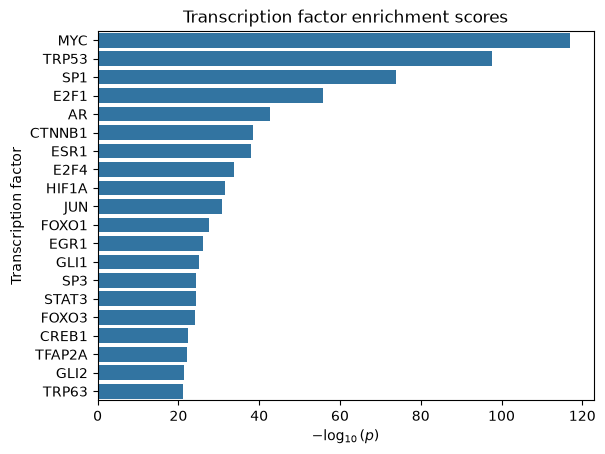

In [13]:
# tf enrichement collectri
import decoupler as dc
collectri = dc.op.collectri(organism="mouse")
tf_list_collectri, tf_stats_collectri  = flowstate.tools.tf_enrich(adata,collectri)

# Transition between cell type across time 


We can then visualize the predicted cell-type transitions along the trajectory. First, the trained model is used to predict the position of each cell at the next timepoint, storing these predictions in adata.obsm["pred"]. A k-nearest-neighbors classifier is then trained on the observed cells to estimate the cell-type of the predicted cells.

In [14]:
#initialize pred
adata.obsm["pred"] = adata.obsm["X_pca"].copy()
#compute  prediction
flowstate.tools.pred(adata, time_key="timepoint", model=model, omics_key="X_pca")

In [15]:
# Compute transition probabilities
transition_probs = flowstate.tools.predict_transition_probabilities_KNN(
    adata,
    time_key='timepoint',
    type_key="cell_type",
    pred_key="pred",
    omics_key='X_pca',
    k=20)

# add source cell types to table
source_types = adata.obs.loc[transition_probs.index, "cell_type"].values
transition_probs["source_type"] = source_types

In [16]:
# Ensure timepoints are sorted
timepoints = np.sort(adata.obs["timepoint"].unique())

`plot_transition_flow_chart` aggregates these predictions into weighted transitions between cell types at consecutive timepoints and displays them as a Sankey flow chart, allowing us to visualize how cell populations evolve along the trajectory. With normalization_type="total", transition weights are normalized relative to the total weighted cell population, so that the sum of all transitions is one, whereas normalization_type="source" normalizes each source cell type independently, so that the outgoing transitions from each cell type sum to one.

In [17]:
! pip install "nbformat>=4.2.0"

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [18]:
# flow with weight normalization type total
fig=flowstate.tools.plot_transition_flow_chart(adata, transition_probs, weight_key='growth', time_key ='timepoint', color_map= colors, normalization_type="total", min_flow=0.01)

NameError: name 'transition_probs' is not defined

In [ ]:
adata

AnnData object with n_obs × n_vars = 33527 × 24967
    obs: 'X_TC_alpha', 'total_TC_alpha', 'unspliced_TC_alpha', 'spliced_TC_alpha', 'p_e', 'p_c_TC', 'sample', 'timepoint', 'rep', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'label_rate', 'doublet_score', 'cell_type', 'proliferation', 'apoptosis', 'growth', 'proliferation_labelled', 'apoptosis_labelled', 'growth_labelled', 'potential'
    var: 'highly_variable', 'mean', 'std'
    uns: 'T_fwd_params', 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'timepoint_colors', 'umap'
    obsm: 'T_fwd_umap', 'X_pca', 'X_umap', 'space', 'v_pca', 'v_pca_scaled', 'X_velo'
    varm: 'PCs'
    layers: 'new', 'total', 'velo_cinetic', 'velo_raw'
    obsp: 'connectivities', 'distances'